# Clasificación de sentimientos turísticos con Transformers

**Objetivo:** Usar la **metodología del notebook "Transformers desde (casi) cero"** (icesi-nlp) aplicada al **dataset de Hugging Face** del notebook de LSTM (sentimientos en textos turísticos México).

**Dataset:** [alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad](https://huggingface.co/datasets/alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad) — mismas columnas `text` y `label` (1–5 estrellas).

**Contenido:**
1. Carga de datos (Hugging Face)
2. Tokenizador (estilo icesi-nlp)
3. Dataset PyTorch y DataLoaders
4. Positional embeddings + Multi-Head Attention + Transformer block
5. Clasificador y entrenamiento (PyTorch Lightning)
6. Evaluación y comparación **LSTM vs Transformer**

In [ ]:
# --- Flujo clásico: TF-IDF + SMOTE/undersampling + RandomForest ---
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Extraer textos y etiquetas
texts = [ej["text"] for ej in full_dataset]
y = [ej["label"] for ej in full_dataset]

# 2. Embeddings TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_emb = vectorizer.fit_transform(texts)

# 3. Balanceo: SMOTE para clases 1 y 2, undersampling para 4 y 5
over = SMOTE(sampling_strategy={1: 1713, 2: 2097}, random_state=42)
under = RandomUnderSampler(sampling_strategy={4: 2126, 5: 2126}, random_state=42)
steps = [('under', under), ('over', over)]
pipeline = Pipeline(steps=steps)
X_resampled, y_resampled = pipeline.fit_resample(X_emb, y)

print('Distribución balanceada:', np.bincount(y_resampled))

# 4. Entrenamiento Random Forest
clf = RandomForestClassifier(random_state=42)
clf.fit(X_resampled, y_resampled)

# 5. Evaluación en test (usamos 20% final del dataset original como test)
split = int(0.8 * len(texts))
X_test = vectorizer.transform(texts[split:])
y_test = y[split:]
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión - Random Forest balanceado')
plt.show()

# Balanceo clásico con embeddings y ML
Este flujo convierte los textos a embeddings TF-IDF, balancea el dataset con SMOTE y undersampling, y entrena un clasificador Random Forest.

---
## Comparación: enfoque LSTM vs enfoque Transformer

 **Datos**  Hugging Face: `alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad`

**Mejoras del enfoque Transformer respecto al LSTM:**
- **Atención paralela:** cada posición puede "ver" todas las demás en un paso (no secuencial como LSTM).
- **Dependencias largas:** la atención permite modelar relaciones entre palabras distantes sin degradación.
- **Positional encoding:** la posición se inyecta de forma fija (sinusoidal), sin parámetros extra.
- **Modularidad:** mismo flujo (tokenizer → embeddings → transformer → clasificador) reutilizable en otros datos.

## 1. Instalación e imports

**Qué hace:** Instala `datasets`, `transformers`, `pytorch-lightning`, `torchmetrics` y demás dependencias. Importa PyTorch, Lightning, métricas y el tokenizador de Hugging Face, para entrenar uno nuevo sobre nuestro corpus.



In [ ]:
# En Google Colab: ejecutar esta celda y luego Runtime → Restart runtime
!pip install -q lightning tensorboard datasets transformers pytorch-lightning torchmetrics scikit-learn matplotlib

import warnings
import os
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from datasets import load_dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tqdm.auto import tqdm
from transformers import AutoTokenizer
try:
    from transformers.models.gpt2.tokenization_gpt2 import bytes_to_unicode
except ImportError:
    def bytes_to_unicode():
        bs = list(range(ord("!"), ord("~") + 1)) + list(range(ord("¡"), ord("¬") + 1)) + list(range(ord("®"), ord("ÿ") + 1))
        cs = bs[:]
        n = 0
        for b in range(2**8):
            if b not in bs:
                bs.append(b)
                cs.append(2**8 + n)
                n += 1
        return dict(zip(bs, (chr(n) for n in cs)))
from enum import Enum
import math

from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 828.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.2 MB/s eta 0:00:00
Dispositivo: cpu


## 2. Carga del dataset desde Hugging Face (mismo que en el notebook LSTM)

**Qué hace:** Descarga el dataset `alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad`. Tiene splits `train` y `test`, con columnas `text` y `label` (1–5). Unimos train y test para luego hacer split 80/10/10 como en icesi-nlp. Las etiquetas 1–5 se mapean a 0–4 para PyTorch.

In [ ]:
from datasets import concatenate_datasets

try:
    dataset_mx = load_dataset("alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad")
except Exception as e:
    print(f"Carga directa falló: {e}")
    data_files = {
        "train": "https://huggingface.co/datasets/alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad/resolve/refs%2Fconvert%2Fparquet/default/train/0000.parquet",
        "test": "https://huggingface.co/datasets/alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad/resolve/refs%2Fconvert%2Fparquet/default/test/0000.parquet",
    }
    dataset_mx = load_dataset("parquet", data_files=data_files)

print(dataset_mx)

id2label = {0: "1_estrella", 1: "2_estrellas", 2: "3_estrellas", 3: "4_estrellas", 4: "5_estrellas"}
label2id = {v: k for k, v in id2label.items()}
NUM_CLASSES = 5

# Unir train y test para luego hacer split 80/10/10 (metodología icesi-nlp)
full_dataset = concatenate_datasets([dataset_mx["train"], dataset_mx["test"]])
# En Colab si hay poco RAM, usar una muestra: full_dataset = full_dataset.select(range(50_000))
print("Total ejemplos:", len(full_dataset))
print("Ejemplo:", full_dataset[0])

README.md:   0%|          | 0.00/495 [00:00<?, ?B/s]

data/train-00000-of-00001-40d9940488cb84(…):   0%|          | 0.00/43.7M [00:00<?, ?B/s]

data/test-00000-of-00001-9cc7bacfd2a73ac(…):   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/176192 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/75510 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 176192
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 75510
    })
})
Total ejemplos: 251702
Ejemplo: {'text': 'el mejor lugar para comer sushi. excelente lugar para comer sushi! toda una experiencia que recomiendo.\nlos\nmartes de ronqueo vale\nmucho la\npena el espectáculo y el\natun que se sirve.', 'label': 5}


## 3. Tokenizador

**Qué hace:**  parte de un tokenizador "beto" y se entrena uno nuevo sobre un iterador del corpus con sentimiento, con vocabulario de 50k tokens. Así el tokenizador se adapta al dominio turístico. Para no saturar memoria, se usa una muestra (por ejemplo 25_000 textos) para entrenar el tokenizador.

In [ ]:
from transformers import AutoTokenizer

# Tokenizador BETO
tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-uncased")

# Iterator para entrenar un nuevo vocabulario si quieres ampliarlo
sample_size = min(25_000, len(full_dataset))

def batch_iterator(batch_size=100):
    for i in range(0, sample_size, batch_size):
        batch = full_dataset[i : i + batch_size]["text"]
        yield batch

# Entrenar un vocabulario nuevo sobre tus datos
sentimientos_tokenizer = tokenizer.train_new_from_iterator(
    batch_iterator(), vocab_size=50000
)

# Añadir token especial de padding
sentimientos_tokenizer.add_special_tokens({"pad_token": "[PAD]"})

print("Vocabulario:", sentimientos_tokenizer.vocab_size)

Vocabulario: 50000


prueba y revision basica de tokenizador BETO

In [ ]:
from transformers import AutoTokenizer

# Cargar tokenizador BETO
spanish_tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-uncased")

# Ordenar vocabulario por índice
tokens = sorted(spanish_tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)

print(f"Vocabulario: {spanish_tokenizer.vocab_size} tokens")

# Primeros 15 tokens
print("Primeros 15 tokens:")
print([spanish_tokenizer.convert_tokens_to_string([t]) for t, _ in tokens[:15]])

# 15 tokens de en medio (ejemplo en posición 1000–1015)
print("15 tokens de en medio:")
print([spanish_tokenizer.convert_tokens_to_string([t]) for t, _ in tokens[1000:1015]])

# Últimos 15 tokens
print("Últimos 15 tokens:")
print([spanish_tokenizer.convert_tokens_to_string([t]) for t, _ in tokens[-15:]])

Vocabulario: 31002 tokens
Primeros 15 tokens:
['[MASK]', '[PAD]', '[EOS]', '[UNK]', '[CLS]', '[SEP]', '[unused0]', '[unused1]', '[unused2]', '[unused3]', '[unused4]', '[unused5]', '[unused6]', '[unused7]', '[unused8]']
15 tokens de en medio:
['##6', '6', '4', '##4', '##w', 'w', 'e', 'd', '.', 'de', 'l', 'p', 'a', 'c', '##os']
Últimos 15 tokens:
['##0', '##ñ', '##2', '##"', '##x', '##!', '##ú', '##¡', '##9', '##k', '##)', '##-', '##(', '##3', '##5']


## 4. Dataset PyTorch (adaptado de SpanishNewsDataset)

**Qué hace:** Define un `Dataset` que, para cada índice, toma `text` y `label` (1–5), convierte label a 0–4, tokeniza el texto con `max_length` y padding, y devuelve `input_ids`, `attention_mask` y `y` para el dataset de sentimientos (columnas `text` y `label`).

In [ ]:

class SentimientosTuristicosDataset(Dataset):
    def __init__(self, tokenizer, hf_dataset, seq_length=64):#256
        self.tokenizer = tokenizer
        # BETO ya tiene pad_token definido, no es obligatorio reasignarlo
        self.hf_dataset = hf_dataset
        self.seq_length = seq_length
        self.id_2_class_map = id2label
        self.class_2_id_map = label2id
        self.num_classes = NUM_CLASSES

    def __getitem__(self, index):
        text = self.hf_dataset[index]["text"]
        label_raw = self.hf_dataset[index]["label"]

        # Ajusta según tu dataset: aquí supongo etiquetas 0–2
        y = int(label_raw)

        data = self.tokenizer(
            text,
            max_length=self.seq_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids": data["input_ids"].squeeze(0),
            "attention_mask": data["attention_mask"].squeeze(0),
            "y": torch.tensor(y, dtype=torch.long),
        }

    def __len__(self):
        return len(self.hf_dataset)


max_len = 64 #256
sentimientos_dataset = SentimientosTuristicosDataset(
    sentimientos_tokenizer, full_dataset, seq_length=max_len
)

print("Clases:", sentimientos_dataset.num_classes)
print("Ejemplo:", sentimientos_dataset[0])

Clases: 5
Ejemplo: {'input_ids': tensor([    3,   393,   530,   462,   419,   851,  4441,    18,   498,   462,
          419,   851,  4441,     5,   911,   420,   699,   396,   796,    18,
          426,  7174,   376, 26574,   818,   648,   387,   737,   393,  1908,
           66,   393, 15281,   396,   434,  2720,    18,     4,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'y': tensor(5)}


el token "[PAD]" ta esta incluido en el tockenizador BETO

se puede comparar como vario el resultado con respecto a la unidad anterior

In [ ]:


# Texto de ejemplo
texto = "El hotel estaba muy limpio y el personal fue amable."

# Tokenización con truncamiento y padding
tokens = spanish_tokenizer(
    texto,
    max_length=128,#256        # puedes ajustar la longitud máxima
    truncation=True,
    padding="max_length"
)

print(tokens)

{'input_ids': [4, 1039, 3849, 1594, 1355, 8725, 1040, 1039, 2613, 1247, 6391, 1008, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [ ]:
spanish_tokenizer(texto, max_length=128, truncation=True, padding='max_length').tokens()

['[CLS]',
 'el',
 'hotel',
 'estaba',
 'muy',
 'limpio',
 'y',
 'el',
 'personal',
 'fue',
 'amable',
 '.',
 '[SEP]',
 '[PAD]']

definimos el dataset y se nombre cateria e ID de categoria, Tokenización con truncamiento y padding. nota: Para incluir la etiqueta (clase) junto con los datos tokenizados.
El diccionario data ya contiene input_ids, attention_mask y posiblemente token_type_ids.
Al añadir data["y"], estás guardando también la clase objetivo de cada ejemplo, que es lo que el modelo necesita para aprender en una tarea de clasificación


In [ ]:
import torch
import numpy as np
from typing import Dict
from torch.utils.data import Dataset

class SentimientosTuristicosDataset(Dataset):

    def __init__(self, tokenizer, dataset, seq_length: int = 64):
        self.tokenizer = tokenizer
        self.tokenizer.pad_token = "[PAD]"
        self.dataset = dataset
        self.seq_length = seq_length

        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]["label"]))) # Corrected line, this was already OK.
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        # Ensure index is a standard Python int, as Hugging Face datasets expect this.
        idx = int(index)
        text, y = self.dataset[idx]["text"], self.dataset[idx]["label"]
        y = self.class_2_id_map[y]

        data = {
            k: torch.tensor(v)
            for k, v in self.tokenizer(
                text,
                max_length=self.seq_length,
                truncation=True,
                padding="max_length"
            ).items()
        }

        data["y"] = torch.tensor(y, dtype=torch.long)
        return data

    def __len__(self):
        return len(self.dataset)


# Ejemplo de uso
max_len = 128 #256
sentimientos_dataset = SentimientosTuristicosDataset(
    tokenizer=spanish_tokenizer,  # BETO
    dataset=full_dataset,
    seq_length=max_len
)

print("Número de clases:", sentimientos_dataset.num_classes)
print("Ejemplo:", sentimientos_dataset[0])

Número de clases: 5
Ejemplo: {'input_ids': tensor([    4,  1039,  1544,  1646,  1097,  1987, 29823,  1008,  5556,  1646,
         1097,  1987, 29823,  1109,  2029,  1091,  3837,  1041, 21620,  1008,
         1067,  9374,  1009,  4327,  1207, 30957,  2504,  1700,  1032,  4339,
         1039,  7786,  1040,  1039, 27124, 30959,  1041,  1057,  6390,  1008,
            5,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Ahora instanciaremos el dataset entero. Para este experimento, definiremos un tamaño máximo de secuencia de **tokens**. Que según nuestra intuición arriba, debería ser suficiente para la tarea.

In [ ]:
max_len = 128 #longitud maxima de cada texto por invividual 256

# Usamos la clase SentimientosTuristicosDataset
sentimientos_dataset = SentimientosTuristicosDataset(
    tokenizer=spanish_tokenizer,   # BETO
    dataset=full_dataset,          # tu dataset de sentimientos
    seq_length=max_len
)

# Verificamos que el tamaño coincida
assert len(sentimientos_dataset) == len(full_dataset)

print("Número de ejemplos:", len(sentimientos_dataset))
print("Número de clases:", sentimientos_dataset.num_classes)
print("Ejemplo:", sentimientos_dataset[0])

Número de ejemplos: 251702
Número de clases: 5
Ejemplo: {'input_ids': tensor([    4,  1039,  1544,  1646,  1097,  1987, 29823,  1008,  5556,  1646,
         1097,  1987, 29823,  1109,  2029,  1091,  3837,  1041, 21620,  1008,
         1067,  9374,  1009,  4327,  1207, 30957,  2504,  1700,  1032,  4339,
         1039,  7786,  1040,  1039, 27124, 30959,  1041,  1057,  6390,  1008,
            5,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0,

## 5. Train / Val / Test split y DataLoaders

**Qué hace:** División 80% train, 10% val, 10% test (como en icesi-nlp) y creación de DataLoaders con batch_size pequeño para poder ejecutar en GPU limitada. El batch_size se puede subir si hay más memoria.

In [ ]:
batch_size = 32  # puedes ajustar según tu GPU
subsample_ratio = 0.1  # usa 10% del dataset para prototipado rápido

n_total = len(sentimientos_dataset)

# Subsampling opcional para reducir datos
indices = np.random.choice(n_total, size=int(subsample_ratio * n_total), replace=False)
dataset_reduced = torch.utils.data.Subset(sentimientos_dataset, indices)

n_total_reduced = len(dataset_reduced)
n_train = int(0.8 * n_total_reduced)
n_val = int(0.1 * n_total_reduced)
n_test = n_total_reduced - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    dataset_reduced,
    lengths=[n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

Train: 40272 Val: 5034 Test: 5034


busco equilibrar los datos de entrenamiento

In [ ]:
# --- Balanceo de clases con WeightedRandomSampler ---
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# Extraer etiquetas del train_ds de forma robusta
targets = []
for i in range(len(train_ds)):
    item = train_ds[i]
    # Si el item es un dict, accede por clave
    if isinstance(item, dict):
        label = item['y'].item() if hasattr(item['y'], 'item') else int(item['y'])
    else:
        # Si es un objeto, accede por atributo
        label = int(item.y) if hasattr(item, 'y') else int(item)
    targets.append(label)

class_counts = np.bincount(targets)
class_weights = 1. / np.maximum(class_counts, 1)  # Evita división por cero
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoader de entrenamiento balanceado
train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=0, pin_memory=(device.type == "cuda"))

## 6. Positional Embeddings

**Qué hace:** Implementación del *positional encoding* sinusoidal del paper "Attention is All You Need": PE(pos,2i)=sin(pos/10000^(2i/d)), PE(pos,2i+1)=cos(...). Se suma a los embeddings de tokens para inyectar la posición en la secuencia. No tiene parámetros entrenables.

In [ ]:
class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        pos = torch.arange(max_len).unsqueeze(1)
        i = torch.arange(d_model).unsqueeze(0)
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        angle_rads = pos * div_term
        pos_encoding = torch.zeros(max_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.pos_encoding[:, : x.size(1), :]


class TokenAndPosEmbedding(nn.Module):
    def __init__(self, max_len: int, embed_dim: int, vocab_size: int):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = SinusoidPE(max_len, embed_dim)

    def forward(self, x):
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)

emb_dim = 128 # puedes ajustar la dimensión de los embeddings, pero ten en cuenta que modelos más grandes requieren más datos y potencia computacional
tpe = TokenAndPosEmbedding(max_len, emb_dim, sentimientos_tokenizer.vocab_size)
print("TokenAndPosEmbedding listo. emb_dim =", emb_dim)

TokenAndPosEmbedding listo. emb_dim = 128


probando con rope pytorch

- se implementa Rotary Positional Embeddings (RoPE).
- En lugar de sumar un vector de posición al embedding, rota las dimensiones pares e impares con senos y cosenos dependientes de la posición.
- El resultado (x_rot) es un embedding que ya codifica la posición de cada token en la secuencia.


In [ ]:
import torch
import torch.nn as nn

class RoPE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        # x: [batch, seq_len, dim]
        seq_len = x.size(1)
        pos = torch.arange(seq_len, device=x.device).unsqueeze(1)
        freqs = torch.exp(-torch.arange(0, self.dim, 2, device=x.device) / self.dim * torch.log(torch.tensor(10000.0)))
        angles = pos * freqs
        sin, cos = angles.sin(), angles.cos()

        x1 = x[..., ::2]
        x2 = x[..., 1::2]
        x_rot = torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1)
        return x_rot

## 7. Multi-Head Attention y Transformer Block

**Qué hace:**
- **Multi-Head Attention:** Calcula Q, K, V con capas lineales, divide en varias cabezas, aplica scaled dot-product attention (con máscara para no atender a padding) y concatena las cabezas.
- **TransformerBlock:** Una capa de multi-head attention + residual + LayerNorm + FFN (dos lineales con ReLU) + residual + LayerNorm. Es el encoder del transformer

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size: int, num_heads: int = 8):
        super().__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size % num_heads == 0
        self.projection_dim = embed_size // num_heads
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        self.combine_heads = nn.Linear(embed_size, embed_size)

    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None):
        d_k = q.size(-1)
        attn_logits = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            attn_logits = attn_logits.masked_fill(
                mask.reshape(mask.shape[0], 1, 1, -1) == 0, -9e15
            )
        attention = torch.softmax(attn_logits, dim=-1)
        return torch.matmul(attention, v)

    def _separate_heads(self, x, batch_size):
        x = x.reshape(batch_size, -1, self.num_heads, self.projection_dim)
        return x.permute(0, 2, 1, 3)

    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.size()
        q = self._separate_heads(self.query(x), batch_size)
        k = self._separate_heads(self.key(x), batch_size)
        v = self._separate_heads(self.value(x), batch_size)
        weights = self._scaled_dot_product(q, k, v, mask)
        weights = weights.permute(0, 2, 1, 3).reshape(batch_size, seq_len, self.embed_size)
        return self.combine_heads(weights)


class TransformerBlock(nn.Module):
    def __init__(self, emb_dim: int, num_heads: int = 8, dropout: float = 0.3): # se puede ajustar el numero de cabezas y dropout
        super().__init__()
        self.mhatt = MultiHeadAttention(emb_dim, num_heads)
        self.mhatt_dropout = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, emb_dim),
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)

    def forward(self, x, mask=None):
        attn_out = self.mhatt(x, mask)
        attn_out = self.layer_norm1(x + self.mhatt_dropout(attn_out))
        ffn_out = self.ffn(attn_out)
        return self.layer_norm2(attn_out + ffn_out)

## 8. Clasificador (LightningModule)

**Qué hace:** Modelo completo: TokenAndPosEmbedding → TransformerBlock → Flatten → MLP (512→256→num_classes) → LogSoftmax. Se define `training_step`, `validation_step`, `test_step`, `configure_optimizers` y opcionalmente Early Stopping.  con 5 clases (polaridad 1–5 estrellas).

In [ ]:
class SentimientosTransformerClassifier(LightningModule):
    def __init__(self, max_len: int, vocab_size: int, num_classes: int, emb_dim: int, num_heads: int = 8, dropout: float = 0.3):
        super().__init__()
        self.num_classes = num_classes
        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
        self.transformer = TransformerBlock(emb_dim, num_heads, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(max_len * emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
            nn.LogSoftmax(dim=1),
        )
        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x, mask=None):
        embeddings = self.token_embeddings(x)
        attention = self.transformer(embeddings, mask)
        return self.classifier(attention)

    def training_step(self, batch, batch_idx):
        x, mask, y = batch["input_ids"], batch["attention_mask"], batch["y"]
        y_hat = self(x, mask)
        loss = F.nll_loss(y_hat, y)
        self.train_acc(y_hat, y)
        self.log("train_loss", loss, prog_bar=True, on_epoch=True)
        self.log("train_acc", self.train_acc, prog_bar=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, mask, y = batch["input_ids"], batch["attention_mask"], batch["y"]
        y_hat = self(x, mask)
        loss = F.nll_loss(y_hat, y)
        self.val_acc(y_hat, y)
        self.log("val_loss", loss, prog_bar=True, on_epoch=True)
        self.log("val_acc", self.val_acc, prog_bar=True, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, mask, y = batch["input_ids"], batch["attention_mask"], batch["y"]
        y_hat = self(x, mask)
        self.test_acc(y_hat, y)
        self.log("test_acc", self.test_acc, prog_bar=True, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=2e-5, weight_decay=1e-5)

model = SentimientosTransformerClassifier(
    max_len=sentimientos_dataset.seq_length,
    vocab_size=sentimientos_tokenizer.vocab_size,
    num_classes=sentimientos_dataset.num_classes,
    emb_dim=emb_dim,
    num_heads=8,
    dropout=0.3,
)
print(model)

SentimientosTransformerClassifier(
  (token_embeddings): TokenAndPosEmbedding(
    (token_emb): Embedding(50000, 128)
    (pos_emb): SinusoidPE()
  )
  (transformer): TransformerBlock(
    (mhatt): MultiHeadAttention(
      (query): Linear(in_features=128, out_features=128, bias=True)
      (key): Linear(in_features=128, out_features=128, bias=True)
      (value): Linear(in_features=128, out_features=128, bias=True)
      (combine_heads): Linear(in_features=128, out_features=128, bias=True)
    )
    (mhatt_dropout): Dropout(p=0.2, inplace=False)
    (ffn): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=512, out_features=128, bias=True)
    )
    (layer_norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (layer_norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Li

## 9. Entrenamiento

**Qué hace:** Crea un `Trainer` de PyTorch Lightning con Early Stopping (patience=3), TensorBoard y hasta 5 épocas para una ejecución rápida. Ajusta `max_epochs` si quieres entrenar más. El entrenamiento usa el mismo flujo que el notebook icesi-nlp.

In [ ]:
# Instalación para Google Colab (solo se ejecuta en el notebook)
!pip install -q lightning tensorboard

In [ ]:
# Asegurar tensorboard en el mismo Python del kernel (local y Colab)
try:
    import tensorboard
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorboard"])
import importlib
import pytorch_lightning.loggers.tensorboard as _tb_mod
importlib.reload(_tb_mod)

tb_logger = TensorBoardLogger("tb_logs", name="SentimientosTransformer")
callbacks = [EarlyStopping(monitor="val_loss", patience=3, mode="min")]
# Compatible con Google Colab: accelerator="auto" detecta GPU automáticamente
trainer = Trainer(
    max_epochs=5,
    accelerator="auto",
    logger=tb_logger,
    callbacks=callbacks,
)
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ token_embeddings │ TokenAndPosEmbedding │  6.4 M │ train │     0 │
│ 1 │ transformer      │ TransformerBlock     │  198 K │ train │     0 │
│ 2 │ classifier       │ Sequential           │  4.3 M │ train │     0 │
│ 3 │ train_acc        │ MulticlassAccuracy   │      0 │ train │     0 │
│ 4 │ val_acc          │ MulticlassAccuracy   │      0 │ train │     0 │
│ 5 │ test_acc         │ MulticlassAccuracy   │      0 │ train │     0 │
└───┴──────────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 10.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 10.9 M                                                                                               
Total estimated model params size (MB): 43                                                                         
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


## 10. Evaluación en test

**Qué hace:** Evalúa el modelo en el conjunto de test y muestra la precisión. Luego obtiene predicciones para matriz de confusión y reporte de clasificación (como en el notebook LSTM).

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.537743330001831     │
└───────────────────────────┴───────────────────────────┘

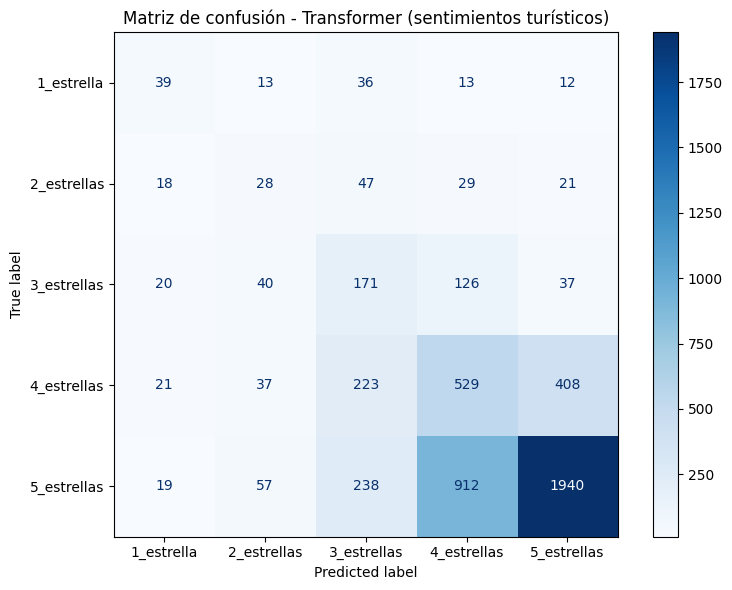

Reporte de clasificación:
              precision    recall  f1-score   support

  1_estrella       0.33      0.35      0.34       113
 2_estrellas       0.16      0.20      0.18       143
 3_estrellas       0.24      0.43      0.31       394
 4_estrellas       0.33      0.43      0.37      1218
 5_estrellas       0.80      0.61      0.69      3166

    accuracy                           0.54      5034
   macro avg       0.37      0.40      0.38      5034
weighted avg       0.61      0.54      0.56      5034



In [ ]:
trainer.test(model, test_loader)

model.eval()
all_preds, all_labels = [], []
dev = next(model.parameters()).device
with torch.no_grad():
    for batch in test_loader:
        x = batch["input_ids"].to(dev)
        mask = batch["attention_mask"].to(dev)
        y = batch["y"]
        logits = model(x, mask)
        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds,
    display_labels=[id2label[i] for i in range(NUM_CLASSES)],
    ax=ax, cmap="Blues",
)
plt.title("Matriz de confusión - Transformer (sentimientos turísticos)")
plt.tight_layout()
plt.show()

print("Reporte de clasificación:")
print(classification_report(all_labels, all_preds, target_names=[id2label[i] for i in range(NUM_CLASSES)]))

## 11. Predicción sobre ejemplos

**Qué hace:** Toma unas frases de ejemplo, las tokeniza con el mismo tokenizador, pasa por el modelo y muestra la clase predicha (1–5 estrellas). Mismo uso que la sección de predicción del notebook LSTM, pero con el modelo Transformer.

In [ ]:
ejemplos = [
    "El mejor hotel en el que me he quedado, servicio excelente.",
    "Muy malo, no volvería. Habitación sucia y el personal desagradable.",
    "Regular, está bien para el precio pero nada del otro mundo.",
]

model.eval()
# Dispositivo del modelo (funciona en Colab y local)
dev = next(model.parameters()).device
for texto in ejemplos:
    data = sentimientos_tokenizer(
        texto,
        max_length=max_len,
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )
    with torch.no_grad():
        logits = model(data["input_ids"].to(dev), data["attention_mask"].to(dev))
    pred_id = logits.argmax(dim=-1).item()
    print(f"Texto: {texto[:60]}...")
    print(f"Predicción: {id2label[pred_id]}")
    print()

Texto: El mejor hotel en el que me he quedado, servicio excelente....
Predicción: 5_estrellas

Texto: Muy malo, no volvería. Habitación sucia y el personal desagr...
Predicción: 5_estrellas

Texto: Regular, está bien para el precio pero nada del otro mundo....
Predicción: 1_estrella



---
## Resumen: relación LSTM vs Transformer (mejoras)

| Mejora | Descripción |
|--------|-------------|
| **Mismos datos** | Ambos usan `alexcom/analisis-sentimientos-textos-turisitcos-mx-polaridad`; este notebook reutiliza la misma carga y mapeo de etiquetas (1–5 → 0–4). |
| **Tokenización** | LSTM: vocabulario propio + padding manual. Transformer (icesi-nlp): tokenizador entrenado sobre el corpus (subwords), mismo flujo en este notebook. |
| **Arquitectura** | LSTM: secuencia procesada paso a paso (recurrente). Transformer: atención sobre toda la secuencia en paralelo + positional encoding; aquí se usa la misma estructura que icesi-nlp (TokenAndPosEmbedding + TransformerBlock + clasificador). |
| **Entrenamiento** | LSTM: loop manual + Early Stopping. Transformer: PyTorch Lightning Trainer + Early Stopping (misma idea, código más limpio). |
| **Evaluación** | Misma métrica (accuracy, matriz de confusión, classification report) y mismo tipo de predicción sobre ejemplos. |

En conjunto, este notebook **combina los datos del notebook LSTM** con la **metodología del notebook icesi-nlp**  no se evidencia una mejora de evaluacion y funcionamiento para estos datos en la comprension interna del contexto de las oraciones, se usaron tecnicas como Undersampling para reducion de datos y Oversampling para aumentada datos en la clasificacion de 1 y 2 estrellas, pero en el funcionamiento la calificaciones en las evaluaciones fuero inferires.